In [2]:
import akshare as ak
import pandas as pd

In [6]:
df=ak.stock_zh_a_hist(symbol="601398",period="daily",start_date="20210101",end_date="20251231")

In [8]:
df.head()

,日期,股票代码,开盘,收盘,最高,最低,成交量,成交额,振幅,涨跌幅,涨跌额,换手率
0,2021-01-04,601398,4.97,5.01,5.01,4.95,3539512,1.762309e+09,1.20,0.4,0.02,0.13
1,2021-01-05,601398,4.99,4.97,4.99,4.94,3710104,1.839471e+09,1.00,-0.8,-0.04,0.14
2,2021-01-06,601398,4.96,4.97,4.98,4.95,3463184,1.717384e+09,0.60,0.0,0.00,0.13
3,2021-01-07,601398,4.97,5.00,5.00,4.95,3190474,1.587575e+09,1.01,0.6,0.03,0.12
4,2021-01-08,601398,5.00,5.00,5.03,4.98,3422030,1.710555e+09,1.00,0.0,0.00,0.13


In [9]:
df["ma5"]=df["收盘"].rolling(window=5).mean()

In [10]:
df[["日期","收盘","ma5"]].head(10)

,日期,收盘,ma5
0,2021-01-04,5.01,NaN
1,2021-01-05,4.97,NaN
2,2021-01-06,4.97,NaN
3,2021-01-07,5.00,NaN
4,2021-01-08,5.00,4.990
5,2021-01-11,4.99,4.986
6,2021-01-12,5.02,4.996
7,2021-01-13,5.06,5.014
8,2021-01-14,5.08,5.030
9,2021-01-15,5.15,5.060


In [12]:
df["ma20"]=df["收盘"].rolling(window=20).mean()

C:\Users\22070\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 24037 (\N{CJK UNIFIED IDEOGRAPH-5DE5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\22070\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 21830 (\N{CJK UNIFIED IDEOGRAPH-5546}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\22070\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 38134 (\N{CJK UNIFIED IDEOGRAPH-94F6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\22070\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 34892 (\N{CJK UNIFIED IDEOGRAPH-884C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\22070\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 21452 (\N{CJK UNIFIED IDEOGRAPH-53CC}) missing from font(s) DejaV

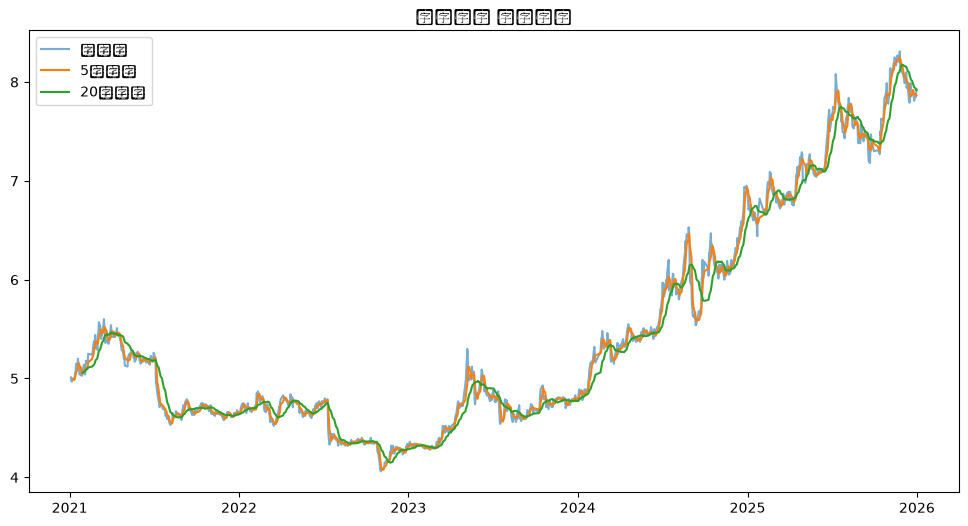

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df["日期"],df["收盘"],label="收盘价",alpha=0.6)
plt.plot(df["日期"],df["ma5"],label="5日均线",linewidth=1.5)
plt.plot(df["日期"],df["ma20"],label="20日均线",linewidth=1.5)
plt.legend()
plt.title("工商银行 双均线图")
plt.show()

In [19]:
df["信号"]=""
df.loc[df["ma5"]>df["ma20"],"信号"]="持仓"
df.loc[df["ma5"]<=df["ma20"],"信号"]="空仓"
df["交易"]=df["信号"].shift(1)+"->"+df["信号"]
买入点=df[df["交易"]=="空仓->持仓"]
卖出点=df[df["交易"]=="持仓->空仓"]
print(f"共找到{len(买入点)}次买入信号,{len(卖出点)}次卖出信号")
买入点[["日期","收盘","ma5","ma20"]].head(5)

共找到37次买入信号,37次卖出信号


,日期,收盘,ma5,ma20
20,2021-02-01,5.14,5.072,5.0655
59,2021-04-02,5.42,5.480,5.4585
65,2021-04-13,5.51,5.460,5.4515
94,2021-05-27,5.26,5.228,5.2250
115,2021-06-28,5.18,5.182,5.1800


In [28]:
初始资金 = 100000
资金 = 初始资金
持股 = 0
资产记录 = []

for i in range(len(df)):
    日期 = df.iloc[i]["日期"]
    收盘价 = df.iloc[i]["收盘"]
    信号 = df.iloc[i]["信号"]
    
    if 信号 == "持仓" and 持股 == 0:
        持股 = 资金 / 收盘价
        资金 = 0
    elif 信号 == "空仓" and 持股 > 0:
        资金 = 持股 * 收盘价
        持股 = 0
    
    总资产 = 资金 + 持股 * 收盘价
    资产记录.append(总资产)

df["总资产"] = 资产记录
最终资产 = 资产记录[-1]
收益率 = (最终资产 - 初始资金) / 初始资金 * 100

print(f"初始资金：{初始资金}元")
print(f"最终资产：{最终资产:.2f}元")
print(f"收益率：{收益率:.2f}%")

初始资金：100000元
最终资产：111691.17元
收益率：11.69%


C:\Users\22070\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 24635 (\N{CJK UNIFIED IDEOGRAPH-603B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\22070\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 36164 (\N{CJK UNIFIED IDEOGRAPH-8D44}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\22070\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 20135 (\N{CJK UNIFIED IDEOGRAPH-4EA7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\22070\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\22070\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 20803 (\N{CJK UNIFIED IDEOGRAPH-5143}) missing from font(s) DejaV

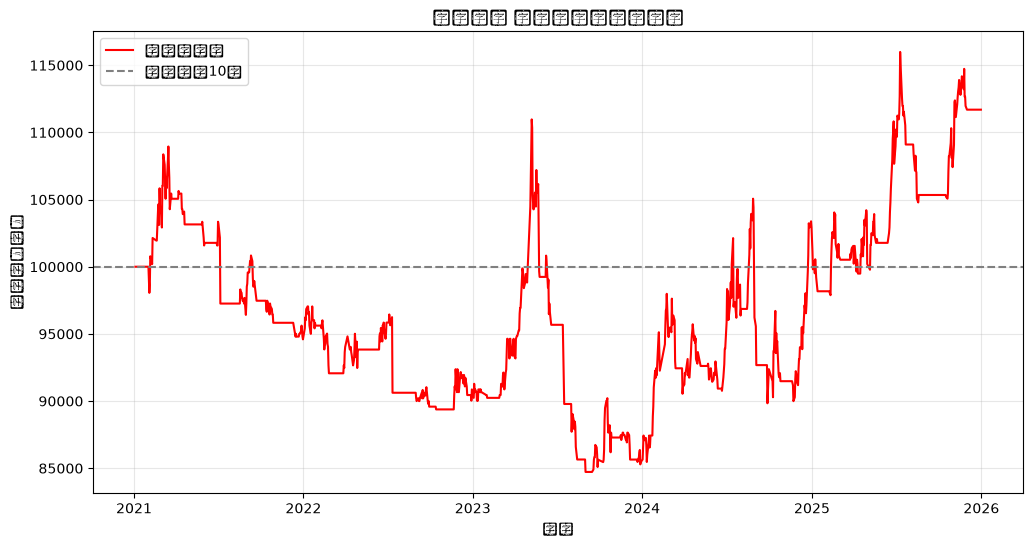

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df["日期"], df["总资产"], label="策略总资产", color="red", linewidth=1.5)
plt.axhline(y=100000, color="gray", linestyle="--", label="初始资金10万")
plt.legend()
plt.title("工商银行 双均线策略资金曲线")
plt.xlabel("日期")
plt.ylabel("总资产（元）")
plt.grid(True, alpha=0.3)
plt.show()

In [30]:
df["累计最高"] = df["总资产"].cummax()
df["回撤"] = (df["总资产"] - df["累计最高"]) / df["累计最高"]
最大回撤 = df["回撤"].min()
最大回撤日期 = df.loc[df["回撤"] == 最大回撤, "日期"].values[0]

print(f"最大回撤：{最大回撤:.2%}")
print(f"发生时间：{最大回撤日期}")
print(f"当时总资产：{df.loc[df['回撤'] == 最大回撤, '总资产'].values[0]:.2f}元")

最大回撤：-23.65%
发生时间：2023-09-01
当时总资产：84723.70元
